### 학습목표
- 배송데이터를 토큰화 및 수치화하여 긍/부정을 분류하는 모델을 학습할 수 있다
- 감성분석을 진행할 수 있다.

### 감성분석
- 텍스트데이터에서 감정,태도,기분 등을 파악하는 방법
- 가장 기본적인 방법으로 긍정과 부정을 판단

In [1]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [2]:
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [3]:
import pandas as pd

In [4]:
data = pd.read_csv('./데이터/naver_shopping.txt',sep='\t',header=None)

In [5]:
data.columns=['평점','리뷰']

In [6]:
data

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
...,...,...
199995,2,장마라그런가!!! 달지않아요
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


- 어떻게하면 데이터를 유의미하게 만들수 있을까? > 평점을 기준으로 긍정/부정을 분류

In [7]:
# 정답데이터 label 만들기 (긍정/부정) 1,2 > 부정 / 4,5 > 긍정
data['평점'].unique()

array([5, 2, 1, 4])

In [8]:
# 정답 데이터 전처리 (긍정 1 / 부정 0)
data['Label'] = data['평점'].apply(lambda x: 1 if x >3 else 0)

In [9]:
!pip install kiwipiepy

### 텍스트 토큰화 및 수치화
1. 토큰화 : 텍스트를 일정 단위로 자르는 작업
    - 단어 (띄어쓰기)
    - 글자
    - 형태소
    - n-gram
2. 수치화 : 토큰화된 결과를 숫자형태로 변경
- 데이터 분석을 위한 특성을 표현하는 과정이라고 하여 "특성추출"
    - One-Hot Encoding
    - 빈도기반 (BoW)
        - CounterVectorize (단순 카운트 기반)
        - TF-IDF (문서 내의 빈도수를 활용)
            - 적은 문서에서 상대적으로 많이 발견될 수록 가치있는 단어

### 토큰화를 위한 한국어 형태소 분석기
- 형태소 : 의미를 가진 말의 최소단위
- Konlpy :한국어 처리를 위한 파이썬 패키지 > 다양한 형태소 분석기들을 포함하고 있음
    - https://konlpy.org/ko/latest/index.html
- Kiwi

#### 1. 토큰화


## 한국어 토큰화 도구 비교
- https://konlpy.org/ko/v0.6.0/morph/

| **토큰화 도구** | **설명** | **장점** | **단점** | **사용하면 좋은 글 유형** |
|----------------|---------|---------|---------|------------------|
| **KoNLPy - Okt** | 트위터에서 개발한 한국어 형태소 분석기 | - 속도가 빠름 <br> - 줄임말, 신조어에 강함 <br> - 명사, 동사, 형용사 태깅 지원 | - 분석 정확도가 상대적으로 낮음 <br> - 긴 문장에서 오탈자나 오류 발생 가능 | - SNS 댓글, 트위터, 카톡 대화 등 구어체 데이터 |
| **KoNLPy - Mecab** | 일본 Mecab을 한국어에 맞게 수정한 형태소 분석기 | - 속도가 가장 빠름 <br> - 비교적 높은 정확도 <br> - 메모리 사용량 적음 | - 윈도우 환경에서 설치가 까다로움 <br> - 사용자 사전 추가 필요 | - 뉴스, 문서 요약, 법률 문서 등 정형 데이터 |
| **KoNLPy - Kkma** | 서울대에서 개발한 형태소 분석기 | - 구문 분석 기능 포함 <br> - 문장 분리 기능 제공 | - 속도가 느림 <br> - 명사 추출 시 과도한 분할 발생 가능 | - 학술 논문, 문서 분석, 보고서 |
| **KoNLPy - Komoran** | Shineware에서 개발한 형태소 분석기 | - 딥러닝 기반으로 정확도 높음 <br> - 사용자 사전 확장 가능 | - 속도가 느린 편 | - 뉴스 기사, 공식 문서, 챗봇 |
| **KoNLPy - Hannanum** | KAIST에서 개발한 한국어 형태소 분석기 | - 어절 분석 및 띄어쓰기 보정 기능 제공 <br> - 구문 분석 가능 | - 속도가 느림 <br> - 비교적 오래된 기술로 최신 트렌드 반영 부족 | - 논문, 신문 기사, 공식 문서 |
| **Kiwi** | 한국어 형태소 분석기 (KyTea 기반) | - 최신 기술 적용 <br> - 속도와 정확도 균형 잡힘 <br> - 신조어, 띄어쓰기 보정 기능 제공 | - 비교적 새로운 도구라 참고 자료 부족 | - 검색 엔진, 챗봇, 감성 분석 |


In [10]:
# 라이브러리 설치하기
# 한국어 형태소 분석기 -> 코엔엘파이
!pip install konlpy
# 키위라이브러리 설치
!pip install kiwipiepy
# Mecab 설치하기
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-02-19 08:06:44--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.24, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-19 08:06:44 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Directory to /content
from https:

In [11]:
# 다양한 형태소 분석기 불러오기 (분석 용도에 맞게 사용)
from kiwipiepy import Kiwi
from konlpy.tag import Kkma
from konlpy.tag import Okt
from konlpy.tag import Mecab

### 형태소 분석기 생성

In [12]:
kiwi = Kiwi() # 최신화 형태소 분석기, 신조어에 강하며 속도도 빠름
kkma = Kkma() # 품사 분류가 정교함. 속도 느림
okt = Okt() # 신조어, 리뷰데이터, 인터넷용어에 강하다
mecab = Mecab() # 속도가 빠름.

In [13]:
#형태소 분석
kiwi.tokenize("아버지가방에들어가신다")

[Token(form='아버지', tag='NNG', start=0, len=3),
 Token(form='가', tag='JKS', start=3, len=1),
 Token(form='방', tag='NNG', start=4, len=1),
 Token(form='에', tag='JKB', start=5, len=1),
 Token(form='들어가', tag='VV', start=6, len=3),
 Token(form='시', tag='EP', start=9, len=1),
 Token(form='ᆫ다', tag='EF', start=9, len=2)]

In [14]:
okt.morphs("아버지가방에들어가신다")

['아버지', '가방', '에', '들어가신다']

In [15]:
kkma.morphs("아버지가방에들어가신다")

['아버지', '가방', '에', '들어가', '시', 'ㄴ다']

In [57]:
mecab.morphs("아버지가방에들어가신다")

['아버지', '가', '방', '에', '들어가', '신다']

In [58]:
# 품사태깅 확인
print(okt.pos("아버지가방에들어가신다"))

[('아버지', 'Noun'), ('가방', 'Noun'), ('에', 'Josa'), ('들어가신다', 'Verb')]


In [59]:
okt.tagset

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [60]:
# 품사태깅 확인
print(kkma.pos("아버지가방에들어가신다"))

[('아버지', 'NNG'), ('가방', 'NNG'), ('에', 'JKM'), ('들어가', 'VV'), ('시', 'EPH'), ('ㄴ다', 'EFN')]


In [61]:
kkma.tagset

{'EC': '연결 어미',
 'ECD': '의존적 연결 어미',
 'ECE': '대등 연결 어미',
 'ECS': '보조적 연결 어미',
 'EF': '종결 어미',
 'EFA': '청유형 종결 어미',
 'EFI': '감탄형 종결 어미',
 'EFN': '평서형 종결 어미',
 'EFO': '명령형 종결 어미',
 'EFQ': '의문형 종결 어미',
 'EFR': '존칭형 종결 어미',
 'EP': '선어말 어미',
 'EPH': '존칭 선어말 어미',
 'EPP': '공손 선어말 어미',
 'EPT': '시제 선어말 어미',
 'ET': '전성 어미',
 'ETD': '관형형 전성 어미',
 'ETN': '명사형 전성 어미',
 'IC': '감탄사',
 'JC': '접속 조사',
 'JK': '조사',
 'JKC': '보격 조사',
 'JKG': '관형격 조사',
 'JKI': '호격 조사',
 'JKM': '부사격 조사',
 'JKO': '목적격 조사',
 'JKQ': '인용격 조사',
 'JKS': '주격 조사',
 'JX': '보조사',
 'MA': '부사',
 'MAC': '접속 부사',
 'MAG': '일반 부사',
 'MD': '관형사',
 'MDN': '수 관형사',
 'MDT': '일반 관형사',
 'NN': '명사',
 'NNB': '일반 의존 명사',
 'NNG': '보통명사',
 'NNM': '단위 의존 명사',
 'NNP': '고유명사',
 'NP': '대명사',
 'NR': '수사',
 'OH': '한자',
 'OL': '외국어',
 'ON': '숫자',
 'SE': '줄임표',
 'SF': '마침표, 물음표, 느낌표',
 'SO': '붙임표(물결,숨김,빠짐)',
 'SP': '쉼표,가운뎃점,콜론,빗금',
 'SS': '따옴표,괄호표,줄표',
 'SW': '기타기호 (논리수학기호,화폐기호)',
 'UN': '명사추정범주',
 'VA': '형용사',
 'VC': '지정사',
 'VCN': "부정 지정사, 형용사 '아니다'",
 'VC

In [62]:
# 품사태깅 확인
print(mecab.pos("아버지가방에들어가신다"))

[('아버지', 'NNG'), ('가', 'JKS'), ('방', 'NNG'), ('에', 'JKB'), ('들어가', 'VV'), ('신다', 'EP+EC')]


In [63]:
mecab.tagset

{'EC': '연결 어미',
 'EF': '종결 어미',
 'EP': '선어말어미',
 'ETM': '관형형 전성 어미',
 'ETN': '명사형 전성 어미',
 'IC': '감탄사',
 'JC': '접속 조사',
 'JKB': '부사격 조사',
 'JKC': '보격 조사',
 'JKG': '관형격 조사',
 'JKO': '목적격 조사',
 'JKQ': '인용격 조사',
 'JKS': '주격 조사',
 'JKV': '호격 조사',
 'JX': '보조사',
 'MAG': '일반 부사',
 'MAJ': '접속 부사',
 'MM': '관형사',
 'NNB': '의존 명사',
 'NNBC': '단위를 나타내는 명사',
 'NNG': '일반 명사',
 'NNP': '고유 명사',
 'NP': '대명사',
 'NR': '수사',
 'SC': '구분자 , · / :',
 'SE': '줄임표 …',
 'SF': '마침표, 물음표, 느낌표',
 'SH': '한자',
 'SL': '외국어',
 'SN': '숫자',
 'SSC': '닫는 괄호 ), ]',
 'SSO': '여는 괄호 (, [',
 'SY': '기타 기호',
 'VA': '형용사',
 'VCN': '부정 지정사',
 'VCP': '긍정 지정사',
 'VV': '동사',
 'VX': '보조 용언',
 'XPN': '체언 접두사',
 'XR': '어근',
 'XSA': '형용사 파생 접미사',
 'XSN': '명사파생 접미사',
 'XSV': '동사 파생 접미사'}

- 품사 필터링 : 일반명사(NNG),형용사(VA),동사(VV)

In [64]:
# kiwi 라이브러리 활용하여 특정 품사만 추출
# "형태소 추출" 컬럼 일반명사, 형용사,동사만을 담기 -> join함수 사용

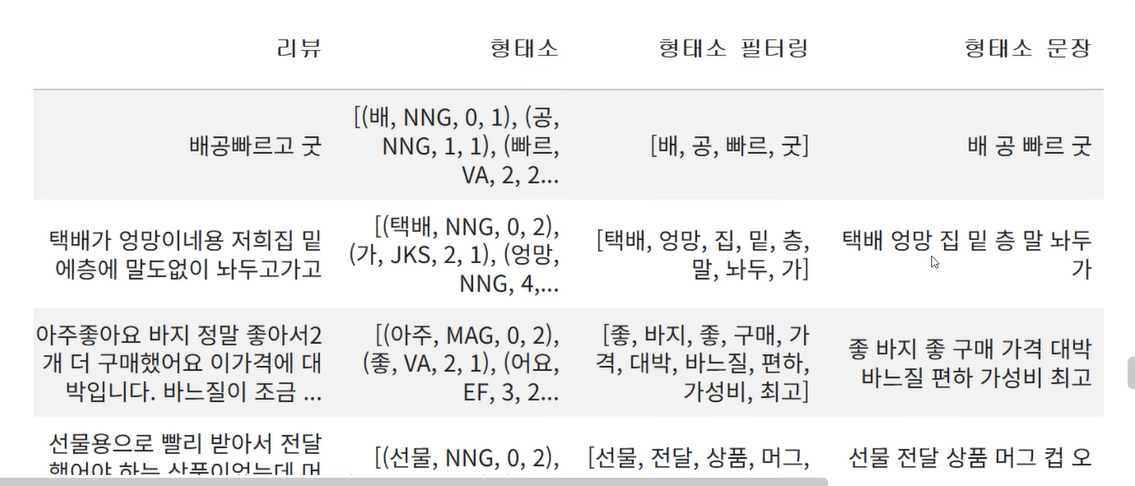

In [17]:
data['형태소'] = data['리뷰'].apply(lambda x:kiwi.tokenize(x))

In [ ]:
data.head()

In [ ]:
kiwi.tokenize("배공빠르고 굿	")

In [18]:
for t in data['형태소'][0]:
    if t.tag in ['NNG','VA','VV']:
        print(t.form)

배
공
빠르
굿


In [19]:
data['형태소 필터링'] = data['형태소'].apply(lambda x: [t.form for t in x if t.tag in ['NNG','VA','VV']])

In [20]:
data['형태소 문장'] = data['형태소 필터링'].apply(lambda x : ' '.join(x))

In [ ]:
data

#### 2. 수치화 (특징 추출)
- BoW
    - CounterVectorize : 빈도수
    - TF-IDF : 모든 문서에 많이 나오면 패널티, 특정문서에 가중치를 주는 방식

In [ ]:
#bow 도구 불러오기
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vec = CountVectorizer()

In [ ]:
sample_text=[
    '우리 반은 설연휴가 지나고 연휴 병을 겪고 있다',
    '나는 요즘 키키의 노래에 푹 빠져있다',
    '우리 반은 출결 이벤트에 푹 빠져있다'
]

In [ ]:
# 1. 단어사전 구축 : 말뭉치 (copus)내에 등장하는 단어를 파악
vec.fit(sample_text)

In [ ]:
# 단어사전의 개수 확인
print("단어사전 내의 단어 개수 확인",len(vec.vocabulary_))

In [ ]:
# b단어사전 내의 단어 확인 > ㄱㄴㄷ 순서
print(vec.vocabulary_)

- bow는 띄어쓰기 기준으로 단어사전을 생성

In [ ]:
# 2. 구축한 단어사전을 기준으로 빈도를 측정하여 수치화
result = vec.transform(sample_text)

In [ ]:
result.toarray()

- "겪고"가 0번임. 즉 result.toarray()에서 첫번째 리스트는 첫번째 문장에 "겪고"라는 말이 포함되어 있음을 의미

- 의미, 문맥정보를 파악하지 않음. 그냥 정확히 일치하는 단어만 개수를 센다.그래서 먼저 토큰화 (형태소분석을 통해 같은 의미의 단어만 남긴뒤) 후,단어 개수를 세기!

### TF-IDF
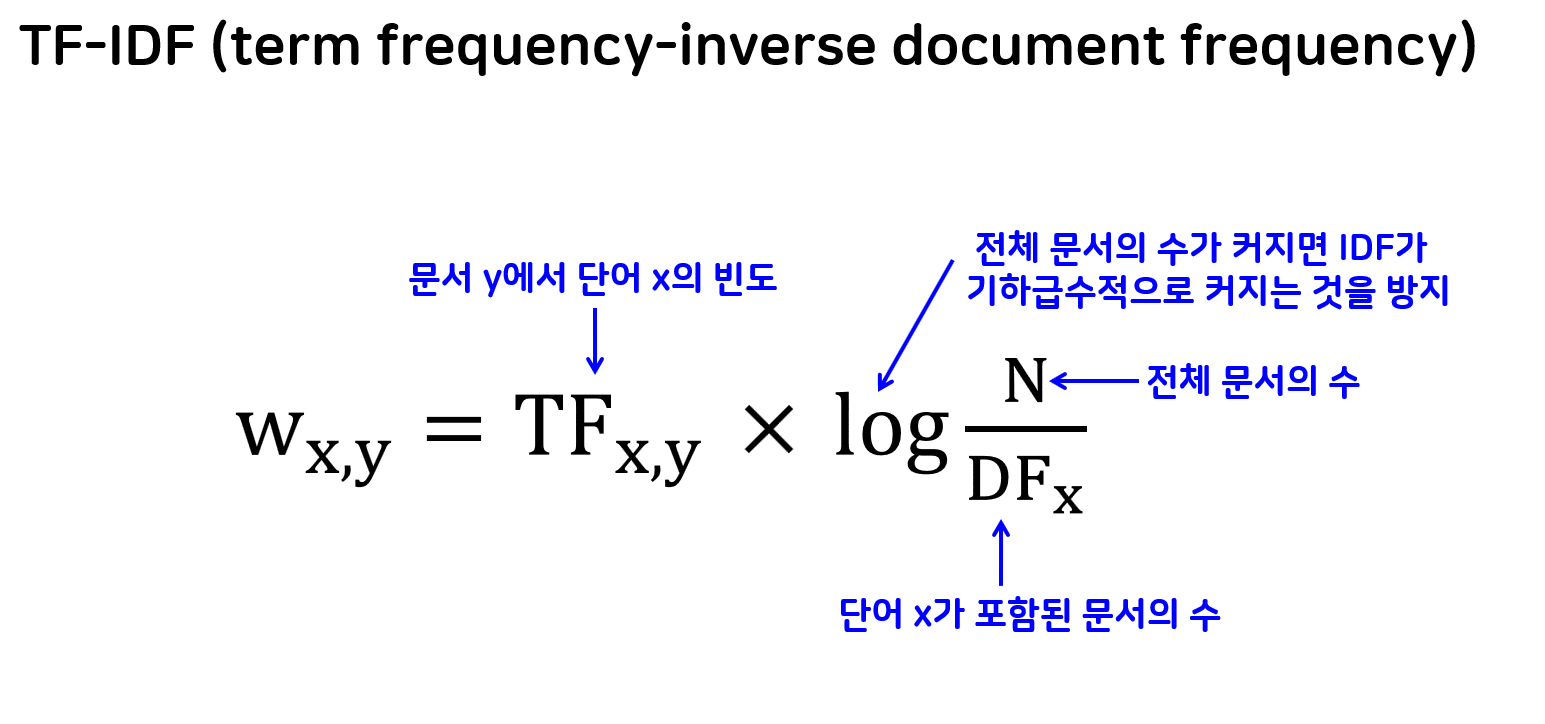

- TF(Term Frequency) : 하나의 문서에서 개별 단어가 등장하는 빈도수
- DF(Documnet Frequency) : 하나의 단어가 전체 말뭉치에 등장한 문서수

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# 도구 생성
tfidf = TfidfVectorizer()

In [ ]:
# 1. 단어사전 구축
tfidf.fit(sample_text)
# 단어사전 길이 확인
print(len(tfidf.vocabulary_))
# 단어사전 확인
print(tfidf.vocabulary_)

In [ ]:
# 2. 단어사전을 기반으로 수치화
result_ = tfidf.transform(sample_text)

In [ ]:
result_.toarray()

- 숫자가 클수록 중요한 단어이다.

In [ ]:
sample_text

- TF-IDF를 통하여 쇼핑리뷰데이터 수치화

In [23]:
#도구 생성
review_tfidf = TfidfVectorizer()

In [ ]:
data['형태소 문장'].apply(lambda x :review_tfidf.fit(x))

- sample_text처럼 그냥 적용하면 됨

In [24]:
#1.단어사전 구축
review_tfidf.fit(data['형태소 문장'])

TfidfVectorizer()

In [25]:
len(review_tfidf.vocabulary_)

20381

In [26]:
print(review_tfidf.vocabulary_)

{'빠르': 8475, '택배': 18009, '엉망': 12189, '놔두': 3361, '바지': 6846, '구매': 1534, '가격': 99, '대박': 3874, '바느질': 6767, '편하': 18722, '가성비': 219, '최고': 17054, '선물': 9385, '전달': 14888, '상품': 9124, '머그': 5809, '당황': 3829, '전화': 14969, '배송': 7200, '누락': 3378, '확인': 19967, '큰일': 17803, '걸리': 788, '생각': 9214, '민트': 6686, '색상': 9187, '예쁘': 12637, '손잡이': 9802, '용도': 13148, '사용': 8836, '추하': 17143, '계란': 1000, '불편': 8162, '코팅': 17623, '묻어나': 6423, '실용': 10824, '보이': 7705, '주문': 15724, '시키': 10647, '회사': 20030, '연락': 12438, '추천': 17132, '드리': 4599, '길이': 2290, '나오': 2739, '지금': 15980, '전문': 14901, '속옷': 9761, '브랜드': 8231, '위생': 13444, '팬티': 18602, '부분': 7921, '신축': 10770, '일반': 14109, '사이즈': 8869, '늘어나': 3498, '베이지': 7526, '살색': 8988, '화면': 19914, '컬러': 17511, '돋보이': 4238, '저렴하': 14777, '촉감': 17002, '무게감': 6263, '멍하': 5899, '친구': 17291, '실내': 10783, '모르': 6096, '이상': 13907, '가게': 95, '운영': 13277, '사장': 8881, '대신': 3891, '이쁘': 13888, '괜찮': 1402, '바퀴': 6860, '고정': 1134, '화장': 19940, '지우': 16060, '거품': 732, 

In [27]:
review_result = review_tfidf.transform(data['형태소 문장'])

In [28]:
review_result.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

###  머신러닝 학습
- 모델 정의 (모델 객체 생성)
- 모델 학습 (fit)
- 모델 예측 (predict)
- 모델 평가 (accuracy, 정확도)

In [29]:
X = review_result
y = data['Label']

In [30]:
X.shape

(200000, 20381)

In [31]:
y.shape

(200000,)

In [32]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,
                                                 random_state=19, # 랜덤 규칙 고정
                                                 stratify=y # 정답 class 비율 조정
                                                 )

In [38]:
X_train.shape

(140000, 20381)

In [39]:
# 모델 정의
from sklearn.linear_model import LogisticRegression #로지스틱회귀모델

In [40]:
model = LogisticRegression()

In [41]:
# 모델 학습
model.fit(X_train,y_train)

LogisticRegression()

In [43]:
# 모델 예측
y_pred = model.predict(X_test)

In [45]:
# 모델 평가
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.7935

In [50]:
# 모델.score(평가용문제,평가용정답) > 알아서 예측 후 평가까지 하여 점수만 출력
model.score(X_test,y_test)

0.7935

### 모델 활용

In [51]:
# 샘플문장 만들기
my_review = ['택배 배송 너무 빨라서 좋았어요. 최고 좋아',
             '이 옷은 오염 심해요. 기분이 나빠. 다시는 안살래요. 별로에요']

In [52]:
model.predict(my_review)
# 그대로 모델에 넣으면 안됨. > 수치화 필요

ValueError: Expected 2D array, got 1D array instead:
array=['택배 배송 너무 빨라서 좋았어요. 최고 좋아' '이 옷은 오염 심해요. 기분이 나빠. 다시는 안살래요. 별로에요'].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [55]:
my_result = review_tfidf.transform(my_review)

In [56]:
model.predict(my_result)

array([1, 0])